# 📊 Telco Customer Churn — Data Cleaning & Preparation
**MLOps Project — Phase 1**


##  1. Import Libraries

In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE

import warnings
warnings.filterwarnings('ignore')

print('✅ Libraries imported successfully')

✅ Libraries imported successfully


## 2. Load the Dataset

In [19]:
# ⚠️ Update the filename if yours is different
df = pd.read_csv('WA_Fn-UseC_-Telco-Customer-Churn.csv')

print(f'Dataset shape: {df.shape}')
print(f'Rows: {df.shape[0]} | Columns: {df.shape[1]}')
df.head()

Dataset shape: (7043, 21)
Rows: 7043 | Columns: 21


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


3. Initial Inspection

In [20]:
# Column names and data types
print('=== Column Info ===')
df.info()

=== Column Info ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043

In [21]:
# Basic statistics for numerical columns
print('=== Statistical Summary ===')
df.describe()

=== Statistical Summary ===


,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [22]:
# Check unique values per column
print('=== Unique Values per Column ===')
for col in df.columns:
    print(f'{col}: {df[col].nunique()} unique values')

=== Unique Values per Column ===
customerID: 7043 unique values
gender: 2 unique values
SeniorCitizen: 2 unique values
Partner: 2 unique values
Dependents: 2 unique values
tenure: 73 unique values
PhoneService: 2 unique values
MultipleLines: 3 unique values
InternetService: 3 unique values
OnlineSecurity: 3 unique values
OnlineBackup: 3 unique values
DeviceProtection: 3 unique values
TechSupport: 3 unique values
StreamingTV: 3 unique values
StreamingMovies: 3 unique values
Contract: 3 unique values
PaperlessBilling: 2 unique values
PaymentMethod: 4 unique values
MonthlyCharges: 1585 unique values
TotalCharges: 6531 unique values
Churn: 2 unique values


##  4. Fix Known Data Issues

> `TotalCharges` is  (string) instead of `float` .

In [23]:
# Check TotalCharges dtype
print(f'TotalCharges dtype before fix: {df["TotalCharges"].dtype}')

# Replace empty strings with NaN and convert to float
df['TotalCharges'] = df['TotalCharges'].replace(' ', np.nan)
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

print(f'TotalCharges dtype after fix: {df["TotalCharges"].dtype}')
print(f'NaN values in TotalCharges: {df["TotalCharges"].isna().sum()}')

TotalCharges dtype before fix: object
TotalCharges dtype after fix: float64
NaN values in TotalCharges: 11


In [24]:
# Drop customerID — it's just an identifier, useless for ML
df.drop(columns=['customerID'], inplace=True)
print('✅ customerID column dropped')

✅ customerID column dropped


## 5. Handle Missing Values

=== Missing Values ===
TotalCharges    11
dtype: int64


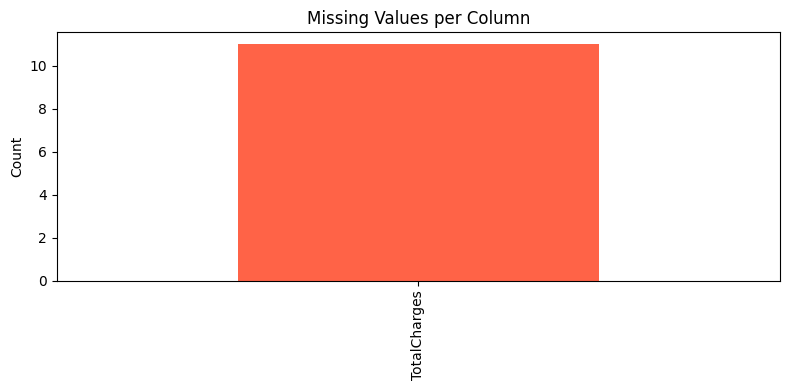

In [25]:
# Check missing values across all columns
missing = df.isnull().sum()
missing = missing[missing > 0]

print('=== Missing Values ===')
print(missing)

# Visualize missing values
plt.figure(figsize=(8, 4))
missing.plot(kind='bar', color='tomato')
plt.title('Missing Values per Column')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

In [26]:
# Strategy: drop rows with missing TotalCharges (only ~11 rows — negligible)
df.dropna(subset=['TotalCharges'], inplace=True)
df.reset_index(drop=True, inplace=True)

print(f'✅ Rows after dropping missing values: {len(df)}')
print(f'Remaining missing values: {df.isnull().sum().sum()}')

✅ Rows after dropping missing values: 7032
Remaining missing values: 0


##  6. Explore the Target Variable (Churn)

=== Churn Distribution ===
Churn
No     5163
Yes    1869
Name: count, dtype: int64

Churn Rate: 26.58%
Retention Rate: 73.42%


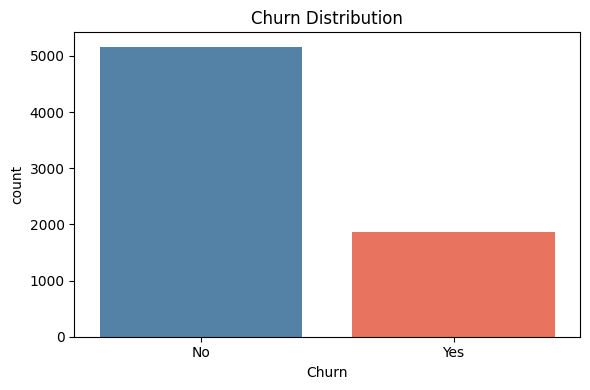

In [27]:
# Churn distribution
churn_counts = df['Churn'].value_counts()
churn_pct = df['Churn'].value_counts(normalize=True) * 100

print('=== Churn Distribution ===')
print(churn_counts)
print(f'\nChurn Rate: {churn_pct["Yes"]:.2f}%')
print(f'Retention Rate: {churn_pct["No"]:.2f}%')

# Plot
plt.figure(figsize=(6, 4))
sns.countplot(x='Churn', data=df, palette=['steelblue', 'tomato'])
plt.title('Churn Distribution')
plt.tight_layout()
plt.show()

##  7. Encode Categorical Variables

In [28]:
# Identify categorical columns
cat_cols = df.select_dtypes(include='object').columns.tolist()
print(f'Categorical columns ({len(cat_cols)}): {cat_cols}')

Categorical columns (16): ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'Churn']


In [29]:
# Binary columns (Yes/No) → encode with LabelEncoder
binary_cols = [col for col in cat_cols if df[col].nunique() == 2]
print(f'Binary columns: {binary_cols}')

le = LabelEncoder()
for col in binary_cols:
    df[col] = le.fit_transform(df[col])
    print(f'  ✅ {col} encoded')

Binary columns: ['gender', 'Partner', 'Dependents', 'PhoneService', 'PaperlessBilling', 'Churn']
  ✅ gender encoded
  ✅ Partner encoded
  ✅ Dependents encoded
  ✅ PhoneService encoded
  ✅ PaperlessBilling encoded
  ✅ Churn encoded


In [30]:
# Multi-category columns → One-Hot Encoding
multi_cols = [col for col in cat_cols if col not in binary_cols]
print(f'Multi-category columns: {multi_cols}')

df = pd.get_dummies(df, columns=multi_cols, drop_first=True)

print(f'\n✅ One-Hot Encoding applied')
print(f'Dataset shape after encoding: {df.shape}')

Multi-category columns: ['MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaymentMethod']

✅ One-Hot Encoding applied
Dataset shape after encoding: (7032, 31)


##  8. Scale Numerical Features

In [31]:
# Separate features and target
X = df.drop(columns=['Churn'])
y = df['Churn']

print(f'Features shape: {X.shape}')
print(f'Target shape: {y.shape}')

Features shape: (7032, 30)
Target shape: (7032,)


# Scale numerical columns
num_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']

scaler = StandardScaler()
X[num_cols] = scaler.fit_transform(X[num_cols])

print('✅ Numerical features scaled with StandardScaler')
X[num_cols].describe().round(3)

## ⚖️ 9. Handle Class Imbalance with SMOTE


In [32]:
# Train/Test split FIRST (80/20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'Train size: {X_train.shape[0]} rows')
print(f'Test size:  {X_test.shape[0]} rows')
print(f'\nTrain churn distribution:\n{y_train.value_counts()}')

Train size: 5625 rows
Test size:  1407 rows

Train churn distribution:
Churn
0    4130
1    1495
Name: count, dtype: int64


In [33]:
# Apply SMOTE only on training data
smote = SMOTE(random_state=42)
X_train_bal, y_train_bal = smote.fit_resample(X_train, y_train)

print(f'✅ SMOTE applied')
print(f'Train size after SMOTE: {X_train_bal.shape[0]} rows')
print(f'\nBalanced train churn distribution:\n{pd.Series(y_train_bal).value_counts()}')

✅ SMOTE applied
Train size after SMOTE: 8260 rows

Balanced train churn distribution:
Churn
0    4130
1    4130
Name: count, dtype: int64


## 💾 10. Save Cleaned Data

In [34]:
# Save processed datasets
X_train_bal.to_csv('X_train.csv', index=False)
X_test.to_csv('X_test.csv', index=False)
pd.Series(y_train_bal, name='Churn').to_csv('y_train.csv', index=False)
pd.Series(y_test, name='Churn').to_csv('y_test.csv', index=False)

# Also save full cleaned dataset
df.to_csv('telco_churn_cleaned.csv', index=False)

print('✅ All files saved successfully!')
print('  - X_train.csv')
print('  - X_test.csv')
print('  - y_train.csv')
print('  - y_test.csv')
print('  - telco_churn_cleaned.csv')

✅ All files saved successfully!
  - X_train.csv
  - X_test.csv
  - y_train.csv
  - y_test.csv
  - telco_churn_cleaned.csv
